<a href="https://colab.research.google.com/github/eddiejaques/ml-code-samples/blob/main/Security%20Breaches%20Dataset/data_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Security Data — Linear Regression

## Dataset
Data sourced from `security_data_10000.csv` (synthetic data generated from original class dataset).

| Column | Description |
|--------|-------------|
| Sector | Industry sector of the company |
| CEO_Gender | Gender of the CEO (Male/Female) |
| Size | Company size (Large, Medium, Small) |
| Security_Invest | Security investment amount |
| Security_Breach_Att | Number of security breach attempts |
| Succ_Sec_Breaches | Number of successful security breaches |
| Sec_Rating | Overall security rating (High/Medium/Low) |
| CEO_Sec_Exp | CEO's level of security experience (High/Medium/Low) |
| LOT_in_Business | Length of time in business (years) |
| Stock_Market | Whether the company is listed on the stock market (Yes/No) |

---

## Data Analysis Plan

1. **EDA** — Understand structure, summary statistics, and distributions
2. **Data Cleaning** — Check and handle missing/null values
3. **Outlier Detection** — Identify outliers using Isolation Forest
4. **Data Types** — Evaluate and encode categorical features
5. **Feature Scaling** — Apply standardization/normalization
6. **Correlation Analysis** — Understand feature relationships
7. **Train-Test Split** — Split dataset before any feature engineering
8. **Feature Engineering** — Apply transformations to both train and test sets
9. **Modelling** — Fit model, predict, and evaluate using MSE and R²

## Step 1 — Load Dataset

In [303]:
#LOAD THE DATASET


import pandas as pd
import numpy as np

security_df = pd.read_csv("https://raw.githubusercontent.com/eddiejaques/ml-code-samples/refs/heads/main/Security%20Breaches%20Dataset/security_data.csv")

security_df.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Banking,Female,Small,17,11,2,Medium,High,13,No
1,Banking,Male,Small,18,12,4,High,Low,9,No
2,Banking,Male,Small,17,12,4,High,Medium,22,No
3,Banking,Male,Small,24,13,1,High,Medium,3,Yes
4,Banking,Male,Small,32,14,3,High,Medium,4,Yes


## Step 2 — Train-Test Split
Split is performed **before** any feature engineering to prevent data leakage.

In [304]:
from sklearn.model_selection import train_test_split
security_df_train, security_df_test = train_test_split(security_df, test_size=0.2, random_state=42)
security_df_train = security_df_train.reset_index(drop=True)
security_df_test = security_df_test.reset_index(drop=True)


## Step 3 — Exploratory Data Analysis (EDA)

In [305]:
security_df_train.head()


,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Hospitality,Male,Medium,91,184,85,Medium,High,21,Yes
1,Banking,Male,Small,24,13,1,High,Medium,3,Yes
2,Hospitality,Male,Large,87,77,33,Low,Medium,8,Yes
3,Health Care,Male,Small,27,20,8,High,High,4,Yes
4,Hospitality,Male,Small,99,77,34,Low,Medium,3,Yes


In [306]:
security_df_train.shape

(48, 10)

In [307]:
security_df_train.describe()


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
count,48.000000,48.000000,48.000000,48.000000
mean,66.604167,54.979167,24.229167,9.125000
std,75.107225,59.456220,24.295381,6.625627
min,12.000000,7.000000,0.000000,1.000000
25%,21.000000,16.250000,4.000000,3.000000
50%,32.000000,40.000000,19.000000,8.000000
75%,93.000000,77.000000,34.000000,14.000000
max,435.000000,321.000000,100.000000,22.000000


## Step 4 — Missing Value Check





In [308]:
security_df_train.isnull().sum()

Sector                 0
CEO_Gender             0
Size                   0
Security_Invest        0
Security_Breach_Att    0
Succ_Sec_Breaches      0
Sec_Rating             0
CEO_Sec_Exp            0
LOT_in_Business        0
Stock_Market           0
dtype: int64

There are no missing values within the dataset (within each column)

array([[<Axes: title={'center': 'Security_Invest'}>,
        <Axes: title={'center': 'Security_Breach_Att'}>],
       [<Axes: title={'center': 'Succ_Sec_Breaches'}>,
        <Axes: title={'center': 'LOT_in_Business'}>]], dtype=object)

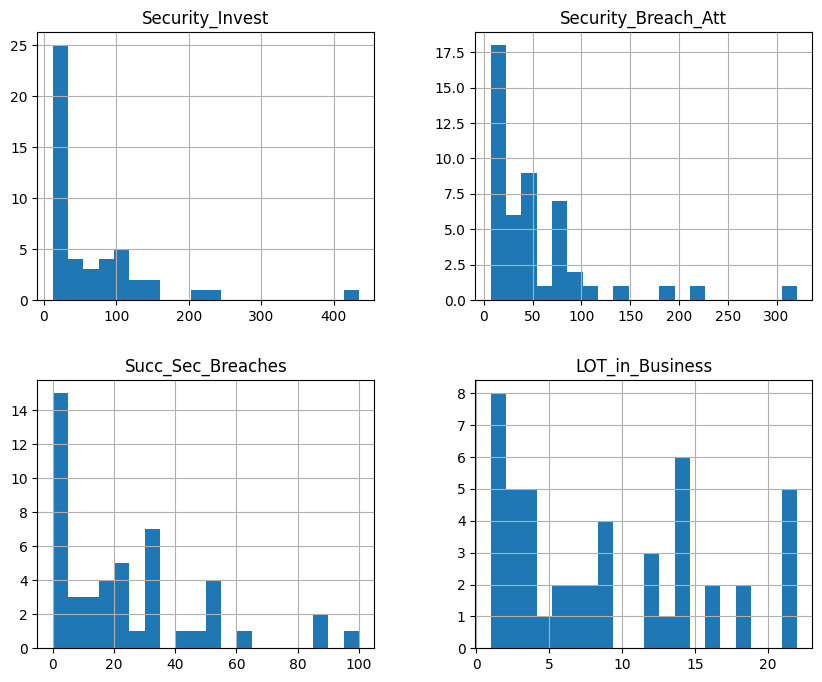

In [309]:
import matplotlib.pyplot as plt


security_df_train.hist(figsize=(10, 8), bins=20)

## Step 5 — Distribution & Outlier Check
Histograms show the distribution of each numeric feature.

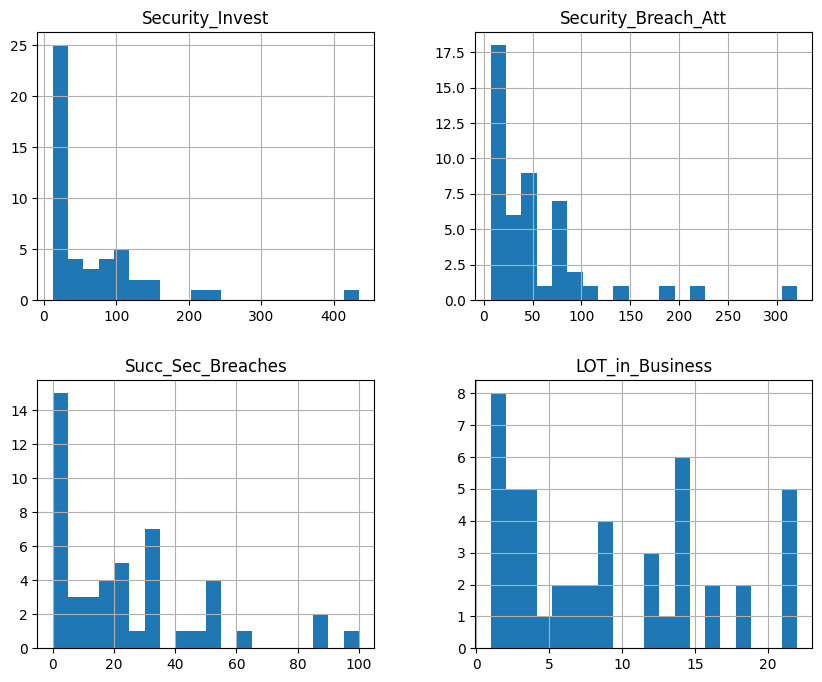

In [310]:
security_df_train.hist(figsize=(10, 8), bins=20)
plt.show()

No outliers that i can see. mostly independent variables left skewed.

In [311]:
print(security_df_train.shape)
print(security_df_test.shape)

(48, 10)
(12, 10)


LOT_in_Business        1.000000
Succ_Sec_Breaches      0.099875
Security_Breach_Att    0.036032
Security_Invest       -0.026236
Name: LOT_in_Business, dtype: float64

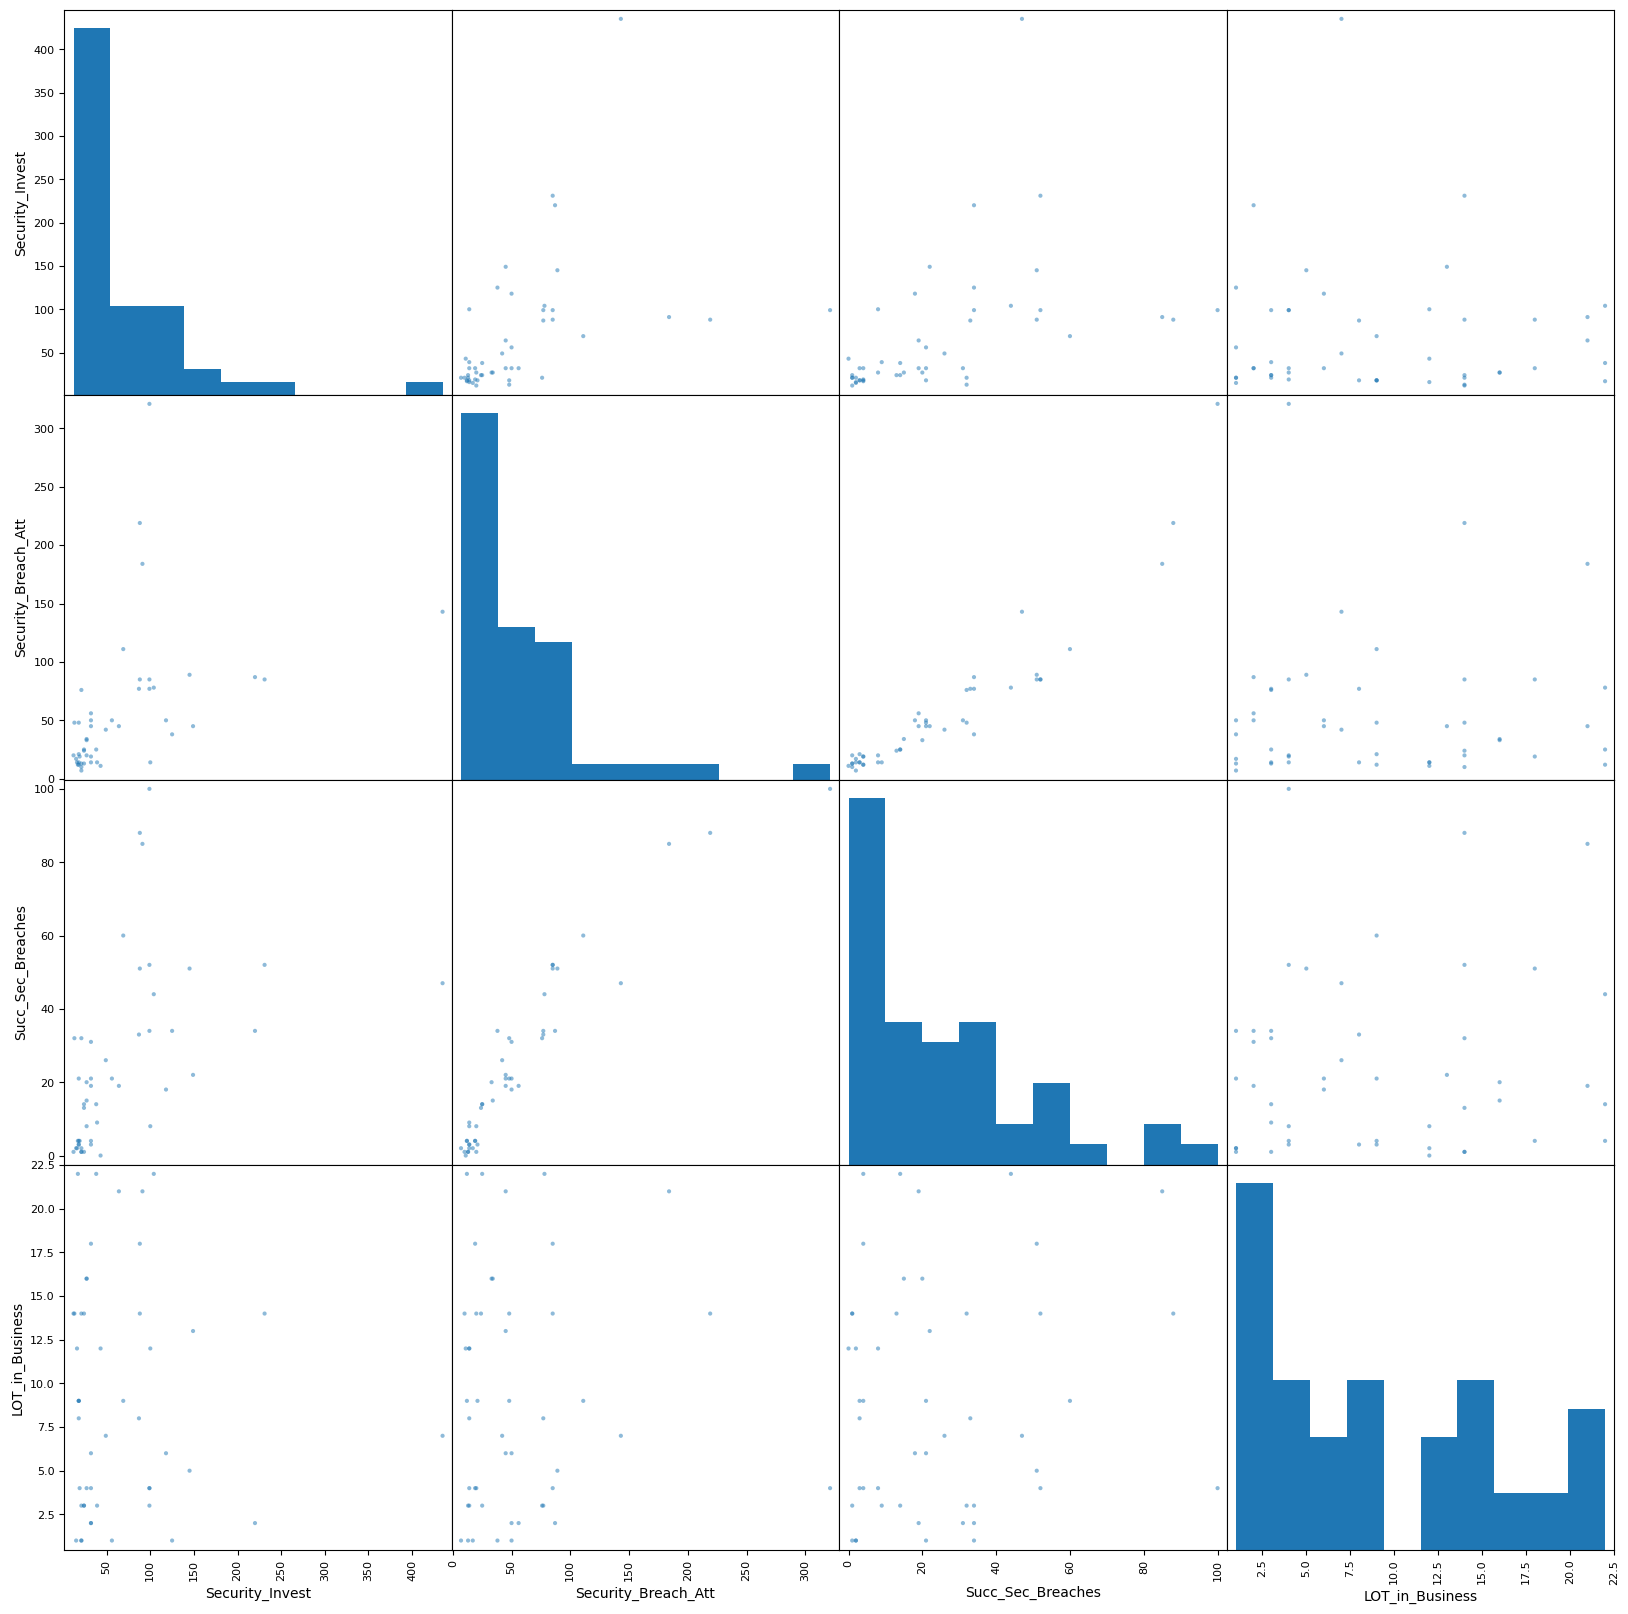

In [312]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

attributes = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches",
              "LOT_in_Business"]
scatter_matrix(security_df_train[attributes], figsize=(20, 20))
#save_fig("scatter_matrix_plot")  # extra code

corr=security_df_train[attributes].corr()
corr["Security_Breach_Att"].sort_values(ascending=False)


corr["LOT_in_Business"].sort_values(ascending=False)


## Step 6 — Correlation Analysis
Scatter matrix and correlation coefficients to understand feature relationships.

No clear correlation between security investment and security breach attempts or successful breaches. There is a positive correlation between breach attempts and successful breaches, which is expected. No meaningful correlation found between length of time in business and breach attempts.

In [313]:
security_df_train_corr =  security_df_train[["Succ_Sec_Breaches","Security_Invest"]]

security_df_train_corr.corr()

,Succ_Sec_Breaches,Security_Invest
Succ_Sec_Breaches,1.000000,0.479426
Security_Invest,0.479426,1.000000


## Step 6b — Create Target Labels

In [314]:
security_df_train_labels=security_df_train["Succ_Sec_Breaches"].copy()
security_df_train=security_df_train.drop("Succ_Sec_Breaches", axis=1)

security_df_test_labels=security_df_test["Succ_Sec_Breaches"].copy()
security_df_test  = security_df_test.drop("Succ_Sec_Breaches", axis=1)

In [315]:
numeric_cols = security_df_train.select_dtypes(include=[np.number]).columns
categorical_cols = security_df_train.select_dtypes(include=[object]).columns

print(numeric_cols)
print(categorical_cols)

print(security_df_train.shape)
print(security_df_test.shape)

Index(['Security_Invest', 'Security_Breach_Att', 'LOT_in_Business'], dtype='str')
Index(['Sector', 'CEO_Gender', 'Size', 'Sec_Rating', 'CEO_Sec_Exp',
       'Stock_Market'],
      dtype='str')
(48, 9)
(12, 9)


/var/folders/bp/yhls2mx94ndcxs30tkpcmjv40000gn/T/ipykernel_53209/2812622303.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = security_df_train.select_dtypes(include=[object]).columns


## Step 7 — Simple Linear Regression
**Question:** Can `Security_Invest` alone predict `Succ_Sec_Breaches`?

Simple linear regression uses **one independent variable** and **one dependent variable**.

In [329]:
security_df_train.head()

,Security_Invest,Security_Breach_Att,LOT_in_Business,Sector,CEO_Gender,Size,Sec_Rating,CEO_Sec_Exp,Stock_Market
1,-0.530547,-0.897833,-0.868199,Banking,Male,Small,High,Medium,Yes
2,1.346646,1.678267,0.000000,Hospitality,Male,Large,Low,Medium,Yes
3,-0.441157,-0.616073,-0.694559,Health Care,Male,Small,High,High,Yes
4,1.704207,1.678267,-0.868199,Hospitality,Male,Small,Low,Medium,Yes
5,0.035591,-0.978337,0.694559,Banking,Male,Small,High,High,Yes


In [330]:
#simple linear regression

print(security_df_train.shape)
print(security_df_test.shape)

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(security_df_train[["Security_Invest"]], security_df_train_labels)

security_df_train_labels_predicted = lin_reg.predict(security_df_train[["Security_Invest"]])

security_df_test_labels_predicted= lin_reg.predict(security_df_test[["Security_Invest"]])

(36, 9)
(12, 9)


In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

print(r2_score(security_df_test_labels, security_df_test_labels_predicted))        # closer to 1 = better
print(mean_squared_error(security_df_test_labels, security_df_test_labels_predicted))  # closer to 0 = better

print(lin_reg.coef_, lin_reg.intercept_)

-0.02464580799001248
346.01008128562734


## Step 8 — Simple Linear Regression (Stronger Feature)
**Question:** Can `Security_Breach_Att` (attempts) predict `Succ_Sec_Breaches` (successes)?

Intuitively, more attempts should lead to more successful breaches — a stronger correlation is expected.

In [ ]:
#simple linear regression

from sklearn.linear_model import LinearRegression

lin_reg_breach = LinearRegression()

lin_reg_breach.fit(security_df_train[["Security_Breach_Att"]], security_df_train_labels)

security_df_train_labels_predicted = lin_reg_breach.predict(security_df_train[["Security_Breach_Att"]])

security_df_test_labels_predicted = lin_reg_breach.predict(security_df_test[["Security_Breach_Att"]])

from sklearn.metrics import mean_squared_error,r2_score


print(r2_score(security_df_test_labels, security_df_test_labels_predicted))        # closer to 1 = better
print(mean_squared_error(security_df_test_labels, security_df_test_labels_predicted))  # closer to 0 = better


#simple linear regression

from sklearn.linear_model import LinearRegression

lin_reg_breach = LinearRegression()

lin_reg_breach.fit(security_df_train[["Security_Breach_Att"]], security_df_train_labels)

security_df_train_labels_predicted = lin_reg_breach.predict(security_df_train[["Security_Breach_Att"]])

security_df_test_labels_predicted = lin_reg_breach.predict(security_df_test[["Security_Breach_Att"]])

from sklearn.metrics import mean_squared_error,r2_score

print(r2_score(security_df_test_labels, security_df_test_labels_predicted))        # closer to 1 = better
print(mean_squared_error(security_df_test_labels, security_df_test_labels_predicted))  # closer to 0 = better

print(lin_reg_breach.coef_, lin_reg_breach.intercept_)


0.13626086899203638
291.67390780225173
0.13626086899203638
291.67390780225173


## Step 9 Impute

In [320]:
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy="median")

# Get numeric columns before imputation
numeric_cols_train = security_df_train.select_dtypes(include=[np.number]).columns
security_df_train_num = imputer.fit_transform(security_df_train.select_dtypes(include=[np.number]))

numeric_cols_test = security_df_test.select_dtypes(include=[np.number]).columns
security_df_test_num = imputer.transform(security_df_test.select_dtypes(include=[np.number]))

# Create DataFrames from imputed numeric arrays, preserving original indices
security_df_train_num_df = pd.DataFrame(security_df_train_num, columns=numeric_cols_train, index=security_df_train.index)
security_df_test_num_df = pd.DataFrame(security_df_test_num, columns=numeric_cols_test, index=security_df_test.index)

# Concatenate numeric and categorical parts
security_df_train = pd.concat([security_df_train_num_df, security_df_train[categorical_cols]], axis=1)
security_df_test = pd.concat([security_df_test_num_df, security_df_test[categorical_cols]], axis=1)

print(security_df_train.shape)
print(security_df_test.shape)

security_df_train.head()

(48, 9)
(12, 9)


,Security_Invest,Security_Breach_Att,LOT_in_Business,Sector,CEO_Gender,Size,Sec_Rating,CEO_Sec_Exp,Stock_Market
0,91.0,184.0,21.0,Hospitality,Male,Medium,Medium,High,Yes
1,24.0,13.0,3.0,Banking,Male,Small,High,Medium,Yes
2,87.0,77.0,8.0,Hospitality,Male,Large,Low,Medium,Yes
3,27.0,20.0,4.0,Health Care,Male,Small,High,High,Yes
4,99.0,77.0,3.0,Hospitality,Male,Small,Low,Medium,Yes


## Step 10 Remove Outliers

In [321]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)

outlier_pred = isolation_forest.fit_predict(security_df_train[numeric_cols])

# Filter both features and labels using the same boolean mask
security_df_train = security_df_train.iloc[outlier_pred == 1]
security_df_train_labels = security_df_train_labels.iloc[outlier_pred == 1]

print(security_df_train.shape)
print(security_df_test.shape)


(36, 9)
(12, 9)


In [322]:
from sklearn.preprocessing import StandardScaler


scalar = StandardScaler()

security_df_train_scalar = scalar.fit_transform(security_df_train[numeric_cols])
security_df_test_scalar = scalar.transform(security_df_test[numeric_cols])

security_df_train_scalar = pd.DataFrame(security_df_train_scalar, columns=numeric_cols, index=security_df_train.index)

security_df_test_scalar = pd.DataFrame(security_df_test_scalar, columns=numeric_cols, index=security_df_test.index)

security_df_train = pd.concat([security_df_train_scalar, security_df_train[categorical_cols]], axis=1)
security_df_test = pd.concat([security_df_test_scalar, security_df_test[categorical_cols]], axis=1)


print(security_df_train.shape)
print(security_df_test.shape)

security_df_train.head()


(36, 9)
(12, 9)


,Security_Invest,Security_Breach_Att,LOT_in_Business,Sector,CEO_Gender,Size,Sec_Rating,CEO_Sec_Exp,Stock_Market
1,-0.530547,-0.897833,-0.868199,Banking,Male,Small,High,Medium,Yes
2,1.346646,1.678267,0.000000,Hospitality,Male,Large,Low,Medium,Yes
3,-0.441157,-0.616073,-0.694559,Health Care,Male,Small,High,High,Yes
4,1.704207,1.678267,-0.868199,Hospitality,Male,Small,Low,Medium,Yes
5,0.035591,-0.978337,0.694559,Banking,Male,Small,High,High,Yes


## Step 11 — Multiple Linear Regression
Using **all features** (numeric + encoded categorical) to predict `Succ_Sec_Breaches`.

Steps:
1. Separate labels from features
2. Impute missing values (fit on train only)
3. Detect outliers using Isolation Forest
4. One-hot encode categorical features
5. Concatenate numeric and categorical features
6. Fit and evaluate

In [325]:
print(security_df_train.shape)
print(security_df_test.shape)

security_df_train_cat = pd.get_dummies(security_df_train[["Sector", "CEO_Gender", "Size", "Sec_Rating", "CEO_Sec_Exp", "Stock_Market"]],dtype=int)

security_df_test_cat = pd.get_dummies(security_df_test[["Sector", "CEO_Gender", "Size", "Sec_Rating", "CEO_Sec_Exp", "Stock_Market"]],dtype=int)

security_df_train_final = pd.concat([security_df_train.drop(categorical_cols,axis=1), security_df_train_cat], axis=1)

security_df_train_final.head()

security_df_test_final = pd.concat([security_df_test.drop(categorical_cols,axis=1), security_df_test_cat], axis=1)

print(security_df_train_final.shape)
print(security_df_test_final.shape)

security_df_train_final.head()


(36, 9)
(12, 9)
(36, 19)
(12, 19)


,Security_Invest,Security_Breach_Att,LOT_in_Business,Sector_Banking,Sector_Health Care,Sector_Hospitality,CEO_Gender_Female,CEO_Gender_Male,Size_Large,Size_Medium,Size_Small,Sec_Rating_High,Sec_Rating_Low,Sec_Rating_Medium,CEO_Sec_Exp_High,CEO_Sec_Exp_Low,CEO_Sec_Exp_Medium,Stock_Market_No,Stock_Market_Yes
1,-0.530547,-0.897833,-0.868199,1,0,0,0,1,0,0,1,1,0,0,0,0,1,0,1
2,1.346646,1.678267,0.000000,0,0,1,0,1,1,0,0,0,1,0,0,0,1,0,1
3,-0.441157,-0.616073,-0.694559,0,1,0,0,1,0,0,1,1,0,0,1,0,0,0,1
4,1.704207,1.678267,-0.868199,0,0,1,0,1,0,0,1,0,1,0,0,0,1,0,1
5,0.035591,-0.978337,0.694559,1,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1


### 9d — Fit Multiple Linear Regression

In [326]:
from sklearn.linear_model import LinearRegression

mul_lin_reg= LinearRegression()

mul_lin_reg.fit(security_df_train_final, security_df_train_labels)

security_df_train_labels_predicted= mul_lin_reg.predict(security_df_train_final)

security_df_test_labels_predicted = mul_lin_reg.predict(security_df_test_final)


In [327]:
from sklearn.metrics import mean_squared_error,r2_score


print(r2_score(security_df_test_labels, security_df_test_labels_predicted))        # closer to 1 = better
print(mean_squared_error(security_df_test_labels, security_df_test_labels_predicted))  # closer to 0 = better


-1.0622495455448502
696.3958934111765


### 9e — Evaluation — Multiple Linear Regression

In [328]:
import plotly.express as px
import pandas as pd

plot_df = pd.DataFrame({"Actual": security_df_test_labels, "Predicted": security_df_test_labels_predicted})

fig = px.scatter(plot_df, x="Actual", y="Predicted", opacity=0.3,
                 title="Actual vs Predicted — Succ_Sec_Breaches")

fig.add_shape(type="line", x0=0, y0=0, x1=60, y1=60,
              line=dict(color="red", dash="dash"))

fig.show()
